<a href="https://colab.research.google.com/github/ShachiPradhan/CODSOFT_TASKNO_4/blob/main/salesprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving advertising.csv to advertising.csv


In [2]:
# ============================================================
# SALES PREDICTION USING PYTHON
# Dataset: advertising.csv (200 rows, 4 columns)
# ============================================================

# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

# 2. Load the dataset
df = pd.read_csv("advertising.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (200, 4)

First 5 rows:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Statistical Summary:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.7500

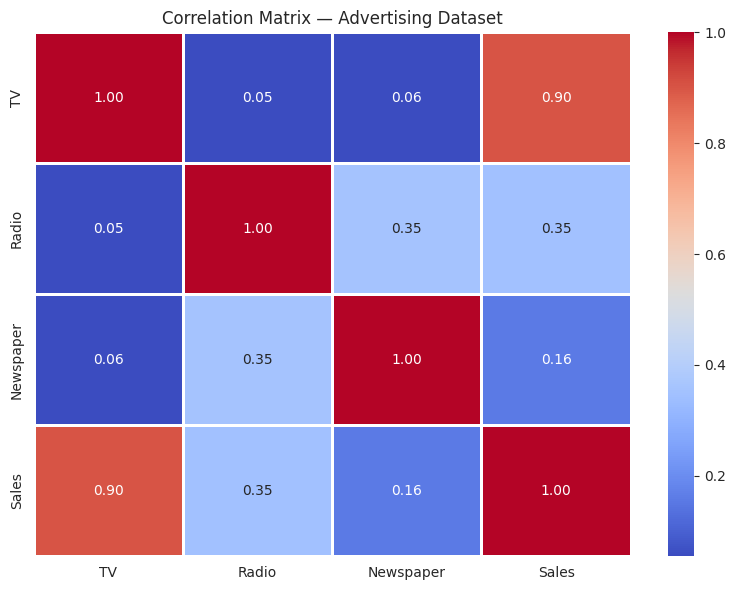

In [3]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title("Correlation Matrix — Advertising Dataset")
plt.tight_layout()
plt.show()

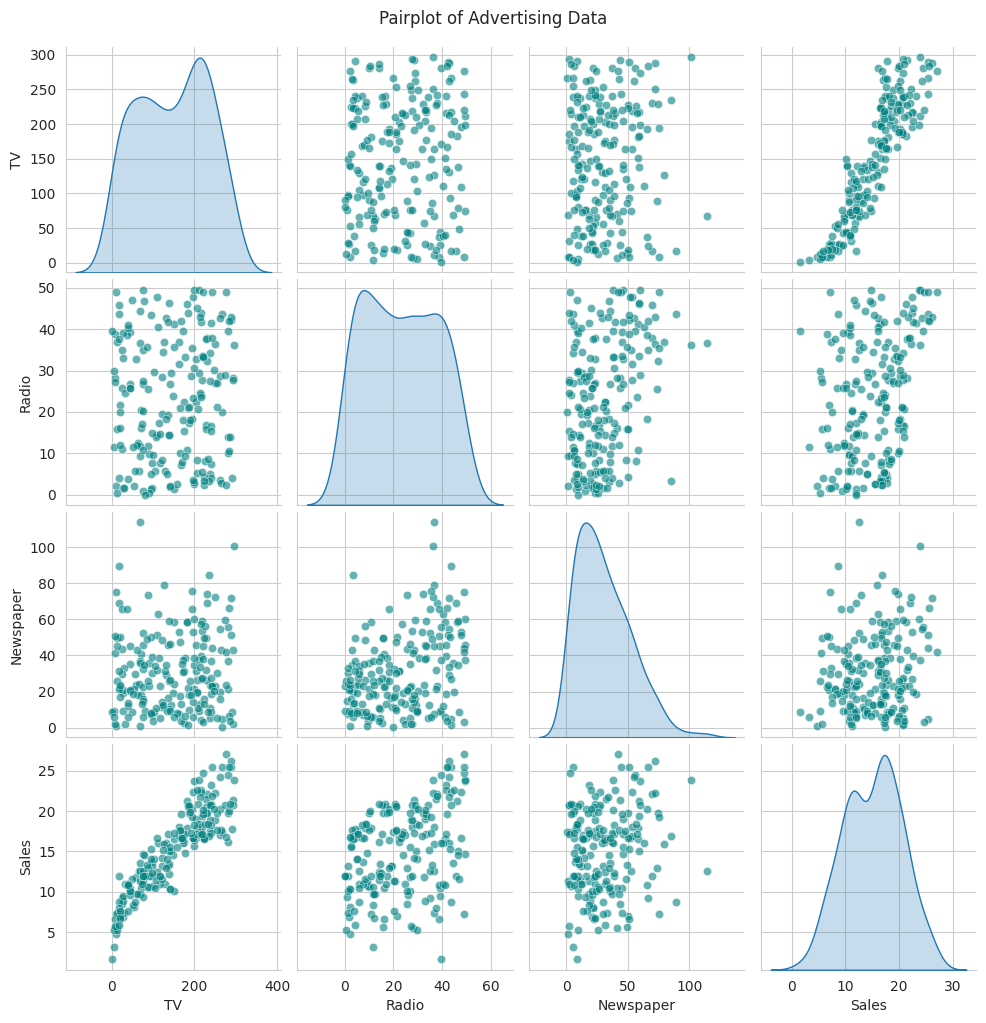

In [4]:
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.6, 'color': 'teal'})
plt.suptitle("Pairplot of Advertising Data", y=1.02)
plt.show()

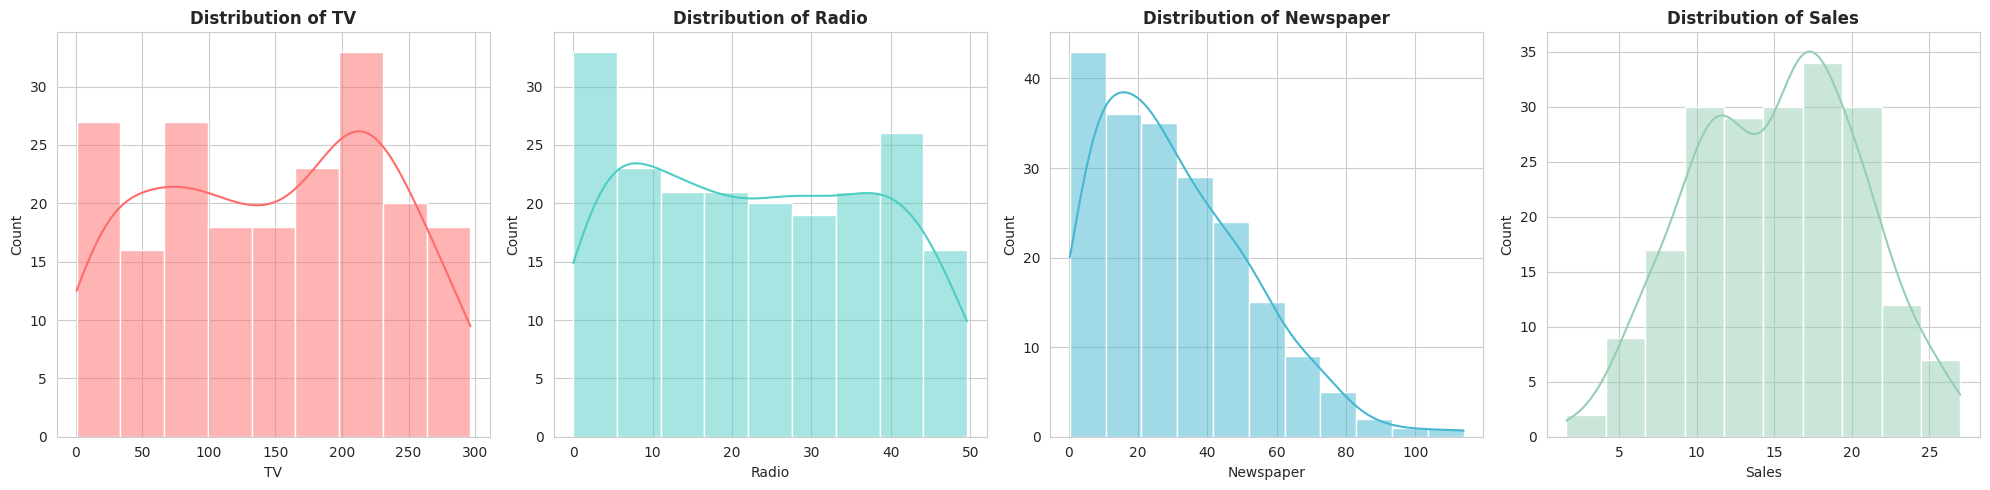

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color=colors[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

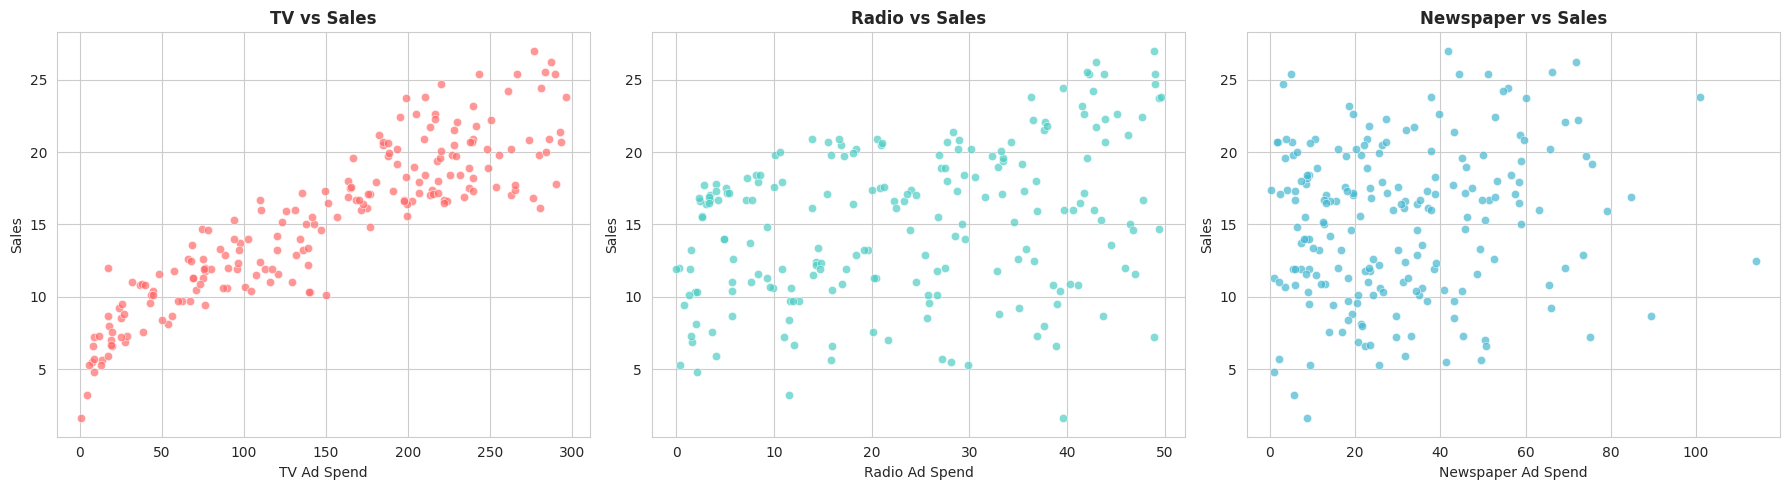

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cols = ['TV', 'Radio', 'Newspaper']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, col in enumerate(cols):
    sns.scatterplot(x=df[col], y=df['Sales'], ax=axes[i], color=colors[i], alpha=0.7)
    axes[i].set_title(f'{col} vs Sales', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(f'{col} Ad Spend')
    axes[i].set_ylabel('Sales')

plt.tight_layout()
plt.show()

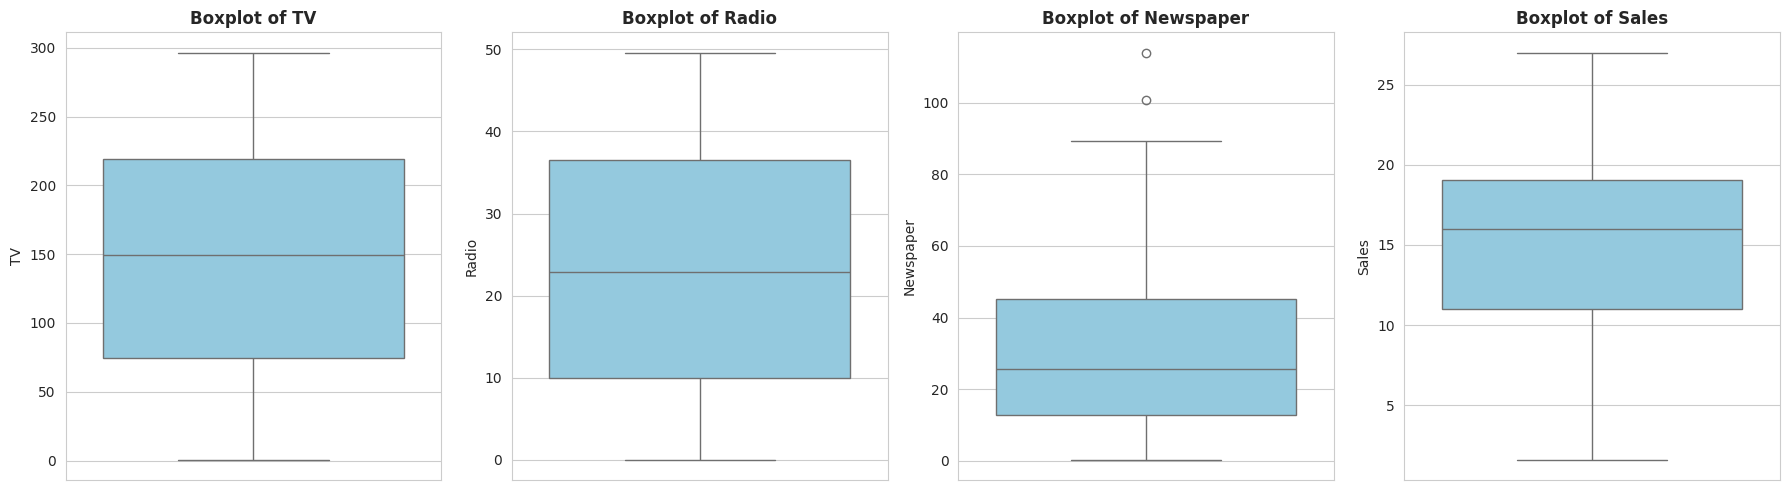

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Create interaction and total spend features
df['TV_Radio_Interaction'] = df['TV'] * df['Radio']
df['Total_Ad_Spend'] = df['TV'] + df['Radio'] + df['Newspaper']
df['TV_per_Radio'] = df['TV'] / (df['Radio'] + 1)  # avoid divide by zero

print("New shape after feature engineering:", df.shape)
print(df.head())

New shape after feature engineering: (200, 7)
      TV  Radio  Newspaper  Sales  TV_Radio_Interaction  Total_Ad_Spend  \
0  230.1   37.8       69.2   22.1               8697.78           337.1   
1   44.5   39.3       45.1   10.4               1748.85           128.9   
2   17.2   45.9       69.3   12.0                789.48           132.4   
3  151.5   41.3       58.5   16.5               6256.95           251.3   
4  180.8   10.8       58.4   17.9               1952.64           250.0   

   TV_per_Radio  
0      5.930412  
1      1.104218  
2      0.366738  
3      3.581560  
4     15.322034  


In [9]:
X = df.drop('Sales', axis=1)
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Testing set : {X_test.shape}")
print(f"\nFeatures used:\n{list(X.columns)}")

Training set: (160, 6)
Testing set : (40, 6)

Features used:
['TV', 'Radio', 'Newspaper', 'TV_Radio_Interaction', 'Total_Ad_Spend', 'TV_per_Radio']


In [10]:
# Helper function
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*45}")
    print(f"📊 {name}")
    print(f"{'='*45}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
res_lr = evaluate_model("Linear Regression", y_test, y_pred_lr)

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)
print("\nFeature Coefficients:")
print(coef_df)
print(f"\nIntercept: {lr.intercept_:.4f}")


📊 Linear Regression
MAE  : 1.1819
RMSE : 1.5337
R²   : 0.9239

Feature Coefficients:
                Feature  Coefficient
4        Total_Ad_Spend     0.022752
0                    TV     0.021586
1                 Radio     0.020039
2             Newspaper    -0.018874
5          TV_per_Radio     0.003956
3  TV_Radio_Interaction     0.000414

Intercept: 6.0861


In [12]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
res_ridge = evaluate_model("Ridge Regression", y_test, y_pred_ridge)


📊 Ridge Regression
MAE  : 1.1819
RMSE : 1.5337
R²   : 0.9239


In [13]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
res_lasso = evaluate_model("Lasso Regression", y_test, y_pred_lasso)

print("\nLasso Coefficients (note zeros = feature removed):")
print(pd.DataFrame({'Feature': X.columns, 'Coeff': lasso.coef_}))


📊 Lasso Regression
MAE  : 1.1885
RMSE : 1.5369
R²   : 0.9236

Lasso Coefficients (note zeros = feature removed):
                Feature     Coeff
0                    TV  0.039904
1                 Radio  0.035971
2             Newspaper -0.000000
3  TV_Radio_Interaction  0.000421
4        Total_Ad_Spend  0.004324
5          TV_per_Radio  0.002957


In [14]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
res_rf = evaluate_model("Random Forest", y_test, y_pred_rf)


📊 Random Forest
MAE  : 0.8476
RMSE : 1.2145
R²   : 0.9523


In [15]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
res_gb = evaluate_model("Gradient Boosting", y_test, y_pred_gb)


📊 Gradient Boosting
MAE  : 0.7887
RMSE : 1.1421
R²   : 0.9578


               Model       MAE      RMSE        R2
0  Gradient Boosting  0.788713  1.142108  0.957788
1      Random Forest  0.847650  1.214506  0.952266
2  Linear Regression  1.181905  1.533701  0.923878
3   Ridge Regression  1.181912  1.533703  0.923878
4   Lasso Regression  1.188460  1.536872  0.923563


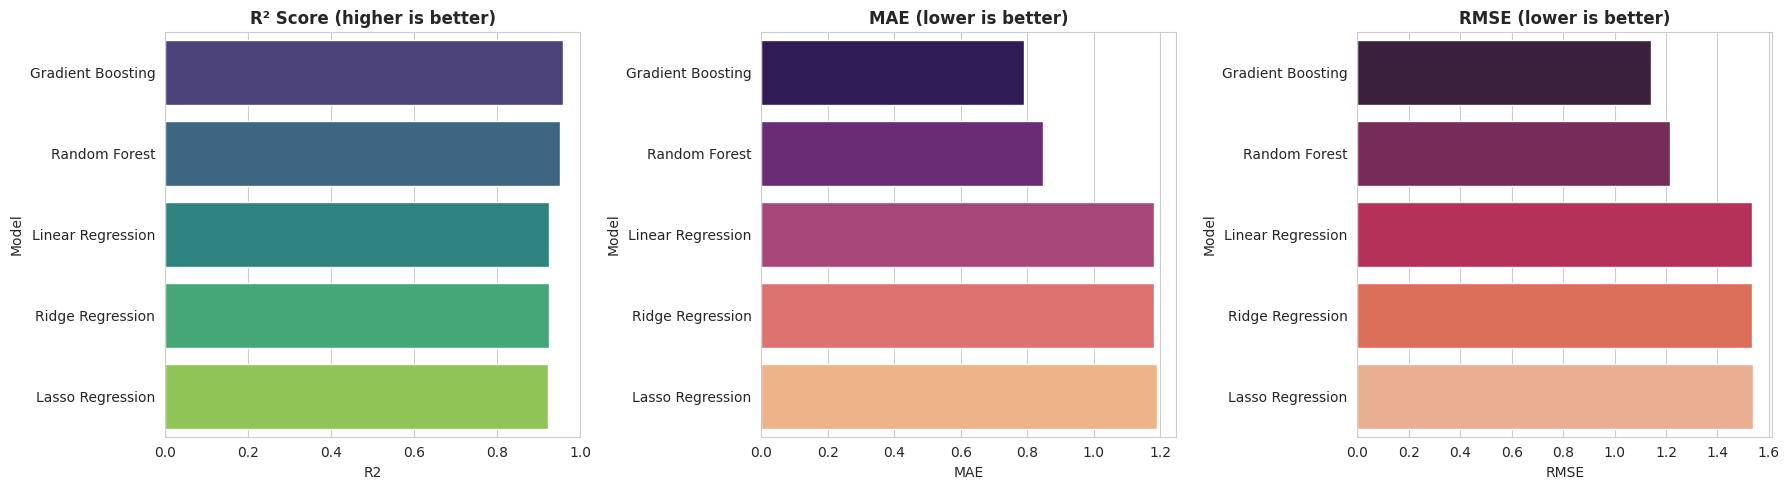

In [16]:
results_df = pd.DataFrame([res_lr, res_ridge, res_lasso, res_rf, res_gb])
results_df = results_df.sort_values(by='R2', ascending=False).reset_index(drop=True)
print(results_df)

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='R2', y='Model', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('R² Score (higher is better)', fontweight='bold')
axes[0].set_xlim(0, 1)

sns.barplot(x='MAE', y='Model', data=results_df, ax=axes[1], palette='magma')
axes[1].set_title('MAE (lower is better)', fontweight='bold')

sns.barplot(x='RMSE', y='Model', data=results_df, ax=axes[2], palette='rocket')
axes[2].set_title('RMSE (lower is better)', fontweight='bold')

plt.tight_layout()
plt.show()

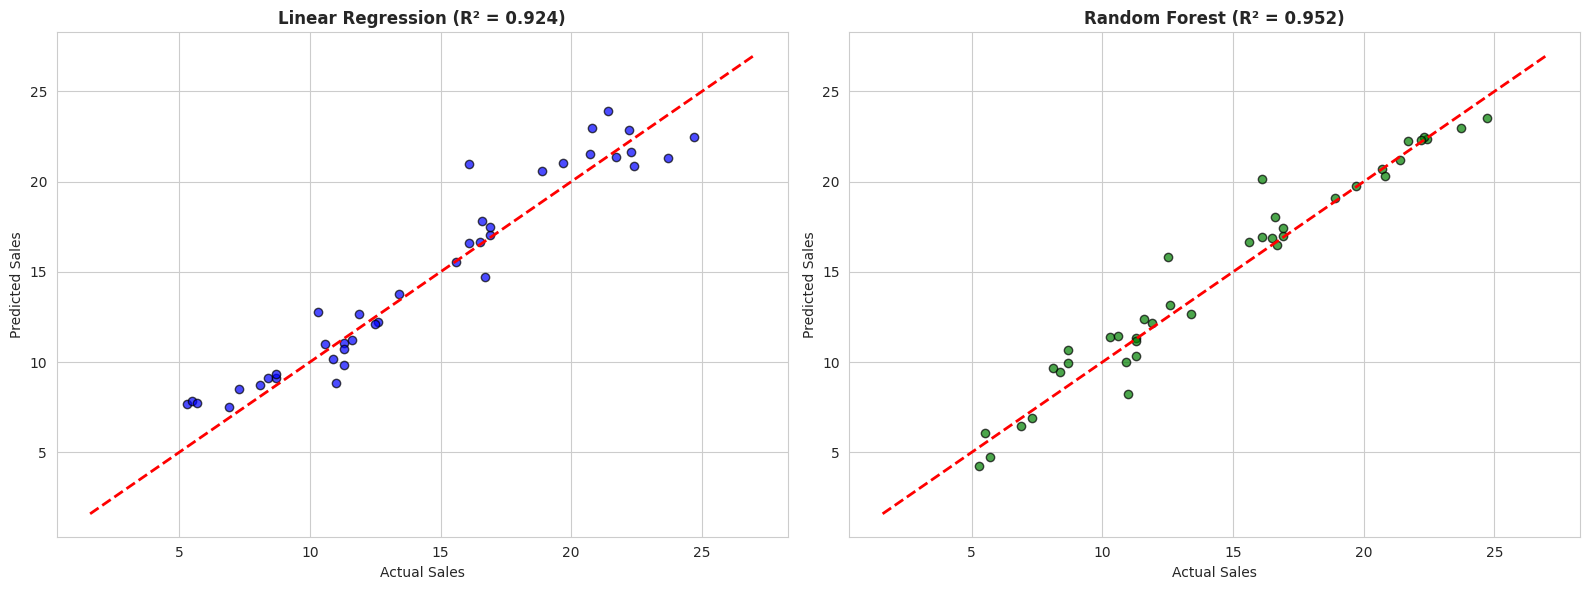

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.7, color='blue', edgecolor='k')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_xlabel("Actual Sales")
axes[0].set_ylabel("Predicted Sales")
axes[0].set_title(f"Linear Regression (R² = {res_lr['R2']:.3f})", fontweight='bold')

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.7, color='green', edgecolor='k')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1].set_xlabel("Actual Sales")
axes[1].set_ylabel("Predicted Sales")
axes[1].set_title(f"Random Forest (R² = {res_rf['R2']:.3f})", fontweight='bold')

plt.tight_layout()
plt.show()

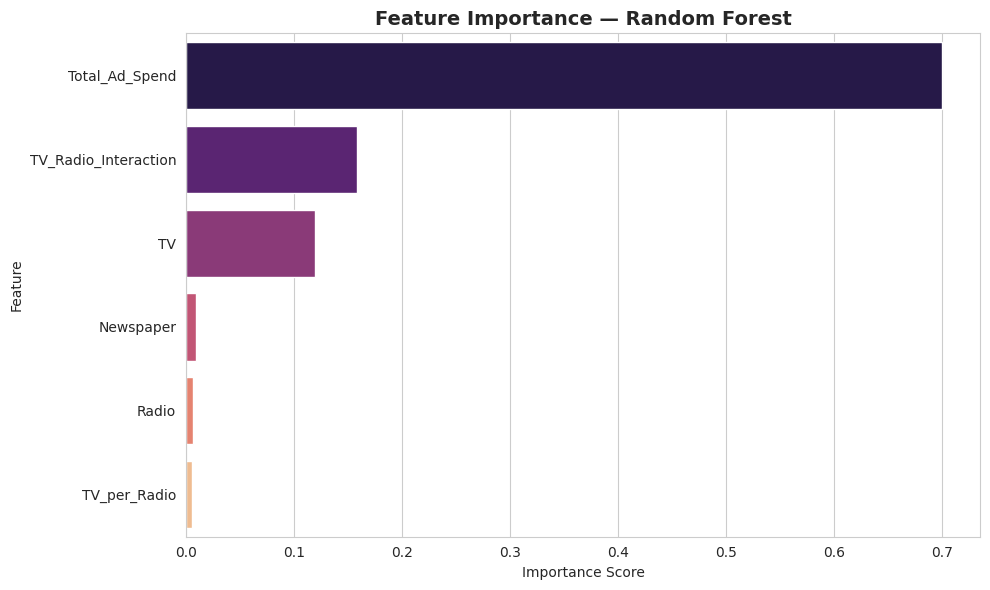

                Feature  Importance
4        Total_Ad_Spend    0.700514
3  TV_Radio_Interaction    0.158594
0                    TV    0.119373
2             Newspaper    0.008979
1                 Radio    0.006975
5          TV_per_Radio    0.005565


In [18]:
importances = rf.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='magma')
plt.title("Feature Importance — Random Forest", fontweight='bold', fontsize=14)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print(feat_imp)

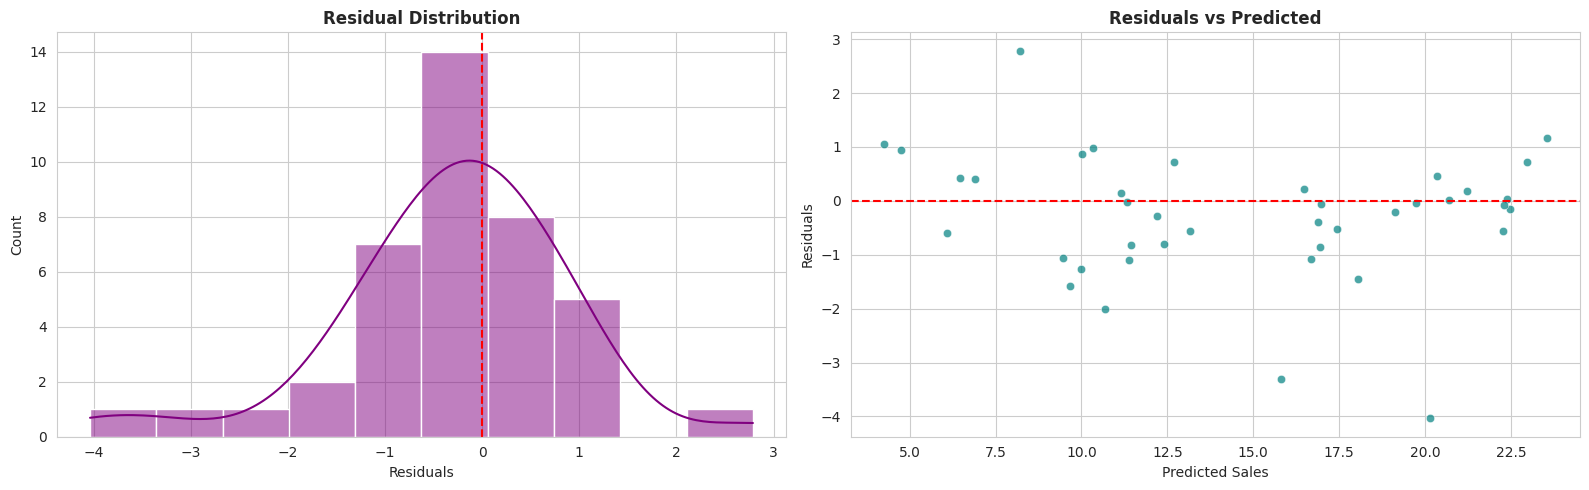

In [19]:
residuals = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
sns.histplot(residuals, kde=True, ax=axes[0], color='purple')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title("Residual Distribution", fontweight='bold')
axes[0].set_xlabel("Residuals")

# Residuals vs Predicted
sns.scatterplot(x=y_pred_rf, y=residuals, ax=axes[1], color='teal', alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title("Residuals vs Predicted", fontweight='bold')
axes[1].set_xlabel("Predicted Sales")
axes[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

In [20]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"5-Fold CV R² Scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

5-Fold CV R² Scores: [0.92963023 0.97423219 0.96085243 0.94498257 0.94111609]
Mean R²: 0.9502
Std Dev: 0.0156


In [21]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print(f"Best CV R²: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
res_best = evaluate_model("Tuned Random Forest", y_test, y_pred_best)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²: 0.9451

📊 Tuned Random Forest
MAE  : 0.8592
RMSE : 1.2247
R²   : 0.9515


In [22]:
joblib.dump(best_rf, "sales_prediction_model.pkl")
print("✅ Model saved as sales_prediction_model.pkl")

# Verify by loading
loaded_model = joblib.load("sales_prediction_model.pkl")

# Test on new data
new_data = pd.DataFrame({
    'TV': [150.0],
    'Radio': [25.0],
    'Newspaper': [30.0],
    'TV_Radio_Interaction': [150.0 * 25.0],
    'Total_Ad_Spend': [150.0 + 25.0 + 30.0],
    'TV_per_Radio': [150.0 / (25.0 + 1)]
})

prediction = loaded_model.predict(new_data)
print(f"\n📈 Predicted Sales for new ad budget: {prediction[0]:.2f} units")

✅ Model saved as sales_prediction_model.pkl

📈 Predicted Sales for new ad budget: 16.52 units


In [23]:

print("="*60)
print("📊 BUSINESS INSIGHTS FROM MODEL")
print("="*60)

# Correlation ranking
corr_rank = df.corr()['Sales'].drop('Sales').sort_values(ascending=False)
print("\n1️⃣ Correlation with Sales (highest to lowest):")
print(corr_rank)

print("\n2️⃣ Feature Importance (Random Forest):")
print(feat_imp.to_string(index=False))

print("\n3️⃣ Recommendations:")
print("   ✅ TV ads drive the most sales — increase TV budget")
print("   ✅ Radio ads have moderate impact — maintain spend")
print("   ❌ Newspaper ads have minimal impact — REALLOCATE budget")
print("   ✅ TV + Radio combined campaigns create synergy")

📊 BUSINESS INSIGHTS FROM MODEL

1️⃣ Correlation with Sales (highest to lowest):
Total_Ad_Spend          0.924917
TV                      0.901208
TV_Radio_Interaction    0.831636
Radio                   0.349631
Newspaper               0.157960
TV_per_Radio            0.087112
Name: Sales, dtype: float64

2️⃣ Feature Importance (Random Forest):
             Feature  Importance
      Total_Ad_Spend    0.700514
TV_Radio_Interaction    0.158594
                  TV    0.119373
           Newspaper    0.008979
               Radio    0.006975
        TV_per_Radio    0.005565

3️⃣ Recommendations:
   ✅ TV ads drive the most sales — increase TV budget
   ✅ Radio ads have moderate impact — maintain spend
   ❌ Newspaper ads have minimal impact — REALLOCATE budget
   ✅ TV + Radio combined campaigns create synergy
